In [573]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [574]:
df=pd.read_csv(r"/content/Multimodal After data imputation.csv")

In [575]:
df.head()

,LOGIMEM,DIGIF,DIGIFLEN,DIGIB,DIGIBLEN,ANIMALS,VEG,TRAILA,TRAILARR,TRAILALI,...,homehobb,judgment,memory,orient,perscare,apoe,sumbox,height,weight,Target
0,13.0,7,6.0,6.0,4.0,23.0,12.0,37.0,1.0,24.0,...,0.0,0.0,0.0,0.0,0.0,44.0,0.0,72.0,184.0,0
1,22.0,10,2.0,8.0,1.0,5.0,18.0,36.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,33.0,0.0,66.0,194.0,0
2,23.0,6,6.0,5.0,4.0,16.0,12.0,41.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,33.0,0.0,62.0,123.0,0
3,9.0,8,6.0,2.0,2.0,14.0,19.0,57.0,6.0,24.0,...,0.5,1.0,1.0,1.0,0.0,34.0,4.0,65.0,172.0,1
4,3.0,6,5.0,4.0,3.0,12.0,8.0,28.0,0.0,24.0,...,0.5,0.5,0.5,0.5,0.0,34.0,2.5,65.0,184.0,1


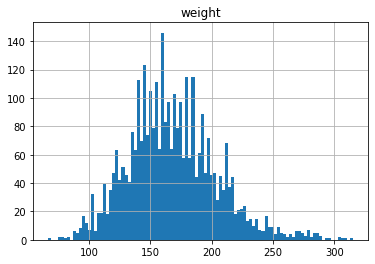

In [576]:
hist=df.hist('weight',bins=100)

In [577]:
mean=np.mean(df['weight'])
print(mean)

168.1741472172352


In [578]:
std=np.std(df['weight'])
print(std)

36.218684842955184


In [579]:
s = np.random.normal(mean, std, 10000)


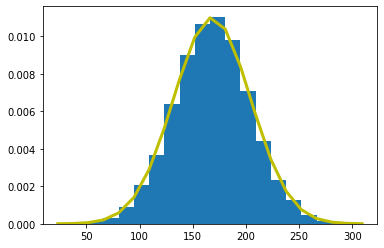

In [580]:
# Create the bins and histogram
count, bins, ignored = plt.hist(s, 20, density=True)
# Plot the distribution curve
plt.plot(bins, 1/(std * np.sqrt(2 * np.pi)) *
    np.exp( - (bins - mean)**2 / (2 * std**2) ),       linewidth=3, color='y')
plt.savefig("weight_norm_distribution.jpg")
plt.show()

In [581]:

 
 
import math
def fx(x,mu,sigma):
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-np.power((x-mu)/sigma,2)/2)

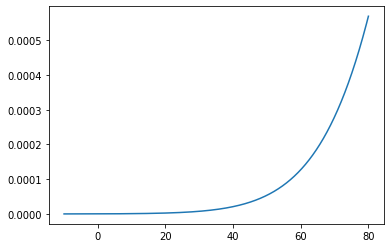

In [582]:
x=np.arange(-10,80,0.001)
plt.plot(x,fx(x,mean,std))
plt.show()

In [583]:
from scipy.integrate import quad
def int(x):
    return x*fx(x,mean,std)
mean,err=quad(int,float('-inf'),float('inf'))
mean

168.1741472172352

In [584]:
from scipy.integrate import quad
def int2(x):
    return fx(x,mean,std)
prob,err=quad(int2,60,80)
prob

0.006046270177389135

In [585]:
from scipy.integrate import quad
def int2(x):
    return fx(x,mean,std)
prob1,err=quad(int2,mean-std,mean+std)
prob2,err=quad(int2,mean-2*std,mean+2*std)
prob3,err=quad(int2,mean-3*std,mean+3*std)
print(prob1)
print(prob2)
print(prob3)

0.6826894921370861
0.9544997361036417
0.99730020393674


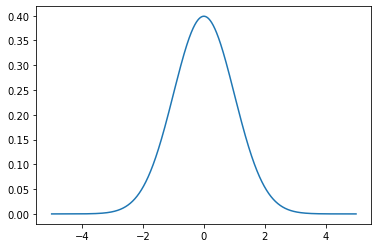

In [586]:
x=np.arange(-5,5,0.001)
plt.plot(x,fx(x,0,1))
plt.show()